<a href="https://colab.research.google.com/github/gudzen2517/colabe/blob/main/work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Эксперименты + отладка + другие варианты реализации алгоритма

In [ ]:
!pip install rasterio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.6/20.6 MB 35.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import cv2 as cv
import matplotlib.image
from shapely.geometry import Polygon
import pyproj
import math

R = 6360000

def reduce_eps(date, coord, zoom):
  if date.shape[0] * epsilon > 1 or date.shape[1] * epsilon > 1:
    epsilon /= zoom
  return epsilon

def cc_to_ll(x, y):
    r = math.sqrt(x**2 + y**2)
    lon = 180 * math.atan2(y,x)/math.pi
    lat = 180 * math.acos(r/R)/math.pi
    return [lat, lon]

def filter_odd_num(element):
  if(len(element) > 10):
    return True
  else:
    return False

def filter_square(element):
  pg = np.reshape(element, (element.shape[0], element.shape[2]))
  if(Polygon(pg).area > 12):
    return True
  else:
    return False

def func(waterLevel : int, out_csv : str, image : str):
  myRasterDF = pd.read_csv(out_csv)
  res = myRasterDF.z.values
  avgX = np.average(myRasterDF['x'])
  avgY = np.average(myRasterDF['y'])
  sizeY = myRasterDF['y'].nunique()
  sizeX = myRasterDF['x'].nunique()
  print(sizeX, sizeY)
  res = np.reshape(res, (sizeY, sizeX))
  if len(np.where(res == waterLevel)[0]) != 0:
    indX = np.where(res == waterLevel)[0][0]
    indY = np.where(res == waterLevel)[1][0]
    img = cv.imread(image, 1)
    imgray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    retval, threshold = cv.threshold(imgray, imgray[indX][indY], 255, cv.THRESH_BINARY_INV)
    matplotlib.image.imsave("/content/drive/MyDrive/vishenka_tresh.png", threshold)
    contours, hierarchy = cv.findContours(threshold,cv.RETR_TREE,cv.CHAIN_APPROX_NONE)
    contours = list(contours)
    print(len(contours))
    c = []
    for i in contours:
      c.append(len(i))
    print(np.mean(c))
    eps = 0.0005
    sq = []
    contours = filter(filter_odd_num, contours)
    contours = list(contours)
    for i in range(0, len(contours)):
      pg = np.reshape(contours[i], (contours[i].shape[0], contours[i].shape[2]))
      sq.append(Polygon(pg).area)
    for i in range(0, len(contours)):
      arclen = cv.arcLength(contours[i], True)
      epsilon = arclen * eps
      contours[i] = cv.approxPolyDP(contours[i], epsilon, True)
    print(len(contours))
    contours = tuple(contours)
    List = []
    for i in contours:
      poligon = []
      for k in i:
        poligon.append([myRasterDF['x'][k[0][1] * sizeX + k[0][0]], myRasterDF['y'][k[0][1] * sizeX + k[0][0]]])
      List.append(poligon)
    print("end")
    return { 'poligon': list(List[0:200]), 'center lon' : avgX, 'center lat' : avgY}
  else:
    return 0
  return

res = func(160, '/content/drive/MyDrive/vishenka_xyz.csv', '/content/drive/MyDrive/vishenka_photo.png')


import plotly.graph_objects as go

fig = go.Figure(go.Scattermapbox(
    mode = "markers",
    lon = [res['center lon']], lat = [res['center lat']],
    marker = {'size': 5, 'color': ["red"]}))
print("end")
fig.update_layout(
    mapbox = {
        'style': "open-street-map",
        'center': { 'lon': res['center lon'], 'lat': res['center lat']},
        'zoom': 12, 'layers': [{
            'source': {
                'type': "FeatureCollection",
                'features': [{
                    'type': "Feature",
                    'geometry': {
                        'type': "MultiPolygon",
                        'coordinates': res['poligon']
                    }
                }]
            },
            'type': "fill", 'below': "traces", 'color' : "blue"}]},
    legend = {'bgcolor' : "red"},
    margin = {'l':0, 'r':0, 'b':0, 't':0})
fig.show()

10000 10000
309042
11.54053170766433
65634
end
end


##Рабочая версия

In [ ]:
import pandas as pd
import numpy as np
import cv2 as cv
import matplotlib.image
from shapely.geometry import Polygon
import pyproj
import math

R = 6360000

def reduce_eps(date, coord, zoom):
  if date.shape[0] * epsilon > 1 or date.shape[1] * epsilon > 1:
    epsilon /= zoom
  return epsilon

def cc_to_ll(x, y):
    r = math.sqrt(x**2 + y**2)
    lon =180 * math.atan2(y,x)/math.pi
    lat = 180 * math.acos(r/R)/math.pi
    return (lat, lon)

def filter_odd_num(element):
  if(len(element) > 4):
    return True
  else:
    return False

def filter_square(element):
  pg = np.reshape(element, (element.shape[0], element.shape[2]))
  if(Polygon(pg).area > 10):
    return True
  else:
    return False

def func(waterLevel : int, out_csv : str, image : str):
  myRasterDF = pd.read_csv(out_csv)
  res = myRasterDF.z.values
  avgX = np.average(myRasterDF['x'])
  avgY = np.average(myRasterDF['y'])
  sizeY = myRasterDF['y'].nunique()
  sizeX = myRasterDF['x'].nunique()
  print(sizeX, sizeY)
  res = np.reshape(res, (sizeY, sizeX))
  if len(np.where(res == waterLevel)[0]) != 0:
    indX = np.where(res == waterLevel)[0][0]
    indY = np.where(res == waterLevel)[1][0]
    img = cv.imread(image, 1)
    imgray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    retval, threshold = cv.threshold(imgray, imgray[indX][indY], 255, cv.THRESH_BINARY_INV)
    matplotlib.image.imsave("/content/drive/MyDrive/vishenka_tresh.png", threshold)
    contours, hierarchy = cv.findContours(threshold,cv.RETR_TREE,cv.CHAIN_APPROX_NONE)
    contours = list(contours)
    eps = 0.0005
    sq = []
    contours = filter(filter_odd_num, contours)
    contours = list(contours)
    for i in range(0, len(contours)):
      pg = np.reshape(contours[i], (contours[i].shape[0], contours[i].shape[2]))
      sq.append(Polygon(pg).area)
    for i in range(0, len(contours)):
      arclen = cv.arcLength(contours[i], True)
      epsilon = arclen * eps
      contours[i] = cv.approxPolyDP(contours[i], epsilon, True)
    contours = tuple(contours)
    List = []
    for i in contours:
      poligon = []
      for k in i:
        poligon.append([myRasterDF['x'][k[0][1] * sizeX + k[0][0]], myRasterDF['y'][k[0][1] * sizeX + k[0][0]]])
      List.append(poligon)
    return { 'poligon': List, 'center lon' : avgX, 'center lat' : avgY}
  else:
    return 0
  return

res = func(16, '/content/drive/MyDrive/Krim_xyz.csv', '/content/drive/MyDrive/Krim_photo.png')
print(res)

import plotly.graph_objects as go

fig = go.Figure(go.Scattermapbox(
    mode = "markers",
    lon = [int(res['center lon'])], lat = [int(res['center lat'])],
    marker = {'size': 8, 'color': ["red"]}))

fig.update_layout(
    mapbox = {
        'style': "open-street-map",
        'center': { 'lon': res['center lon'], 'lat': res['center lat']},
        'zoom': 10, 'layers': [{
            'source': {
                'type': "FeatureCollection",
                'features': [{
                    'type': "Feature",
                    'geometry': {
                        'type': "MultiPolygon",
                        'coordinates': [res['poligon']]
                    }
                }]
            },
            'type': "fill", 'below': "traces", 'color' : "red"}]},
    legend = {'bgcolor' : "red"},
    margin = {'l':0, 'r':0, 'b':0, 't':0})
fig.show()

3600 1800
{'poligon': [[[36.00125000003038, 45.04458333332779], [36.00125000003038, 45.04402777777224], [36.00097222225261, 45.04374999999445], [36.00125000003038, 45.04374999999445], [36.001527777808164, 45.04402777777224], [36.001527777808164, 45.04430555555001]], [[36.03597222225261, 45.05236111110557], [36.03597222225261, 45.05208333332779], [36.03680555558594, 45.05208333332779], [36.03680555558594, 45.05236111110557], [36.03652777780817, 45.05236111110557], [36.03625000003039, 45.05208333332779]], [[36.06763888891928, 45.05791666666113], [36.0673611111415, 45.05763888888335], [36.06680555558595, 45.05763888888335], [36.067083333363726, 45.05736111110557], [36.0673611111415, 45.05763888888335], [36.06763888891928, 45.05763888888335]], [[36.07541666669706, 45.0581944444389], [36.07513888891928, 45.05791666666113], [36.07513888891928, 45.05763888888335], [36.07541666669706, 45.05763888888335]], [[36.25875000003042, 45.05847222221668], [36.25958333336375, 45.05847222221668], [36.2598

In [ ]:
def reduce_eps(date, coord, zoom):
  if date.shape[0] * epsilon > 1 or date.shape[1] * epsilon > 1:
    epsilon /= zoom
  return epsilon

def reduce_map(center, zoom)
  lon = 1
  lat = 0.60 - center[1] * 0.0069
  if zoom > 10:
    lon /= 2**(zoom-10)
    lat /= 2**(zoom-10)
  else:
    lon *= (11 - zoom)
    lat *= (11 - zoom)
  x = [center[0] - lon/2, center[0] + lon/2]#до целых
  y = [center[1] - lat/2, center[1] + lat/2]
  return [x,y]

Результат

In [ ]:
import pandas as pd
import numpy as np
import cv2 as cv
import matplotlib.image
from shapely.geometry import Polygon
import requests as rs
import os
from raster2xyz.raster2xyz import Raster2xyz
import plotly.graph_objects as go
import PIL
from PIL import Image
import plotly.express as px

def files(input_raster : str):
  out_csv = os.path.splitext(input_raster)[0] + "_xyz.csv"
  image = os.path.splitext(input_raster)[0] + "_photo.png"
  rtxyz = Raster2xyz()
  print(input_raster)
  rtxyz.translate(input_raster, out_csv)
  myRasterDF = pd.read_csv(out_csv)
  print("NoValue", myRasterDF.loc[myRasterDF['z'] < 0])
  print("Value", myRasterDF['y'].nunique()*myRasterDF['x'].nunique())
  myRasterDF.loc[myRasterDF['z'] < 0, 'z'] = 0
  res = myRasterDF.z.values
  sizeY = myRasterDF['y'].nunique()
  sizeX = myRasterDF['x'].nunique()
  res = np.reshape(res, (sizeY, sizeX))
  matplotlib.image.imsave(image, res)

'''
def get(x : list, y : list):
  names = []
  if abs(x[1] - x[0]) >= 2 or abs(y[1] - y[0]) >= 2:
    count_x = int(abs(x[1] - x[0]))
    if count_x == 0:
      count_x = 1
    count_y = int(abs(y[1] - y[0]))
    if count_y == 0:
      count_y = 1
    print(count_x, count_y)
    matrix = np.empty((count_x, count_y, 4))
    for i in range(count_x):
      for j in range(count_y):
        matrix[i][j][0] = y[0] + j
        if j == count_y - 1:
          matrix[i][j][1] = y[1]
        else:
          matrix[i][j][1] = y[0] + j + 1
        matrix[i][j][2] = x[0] + i
        if i == count_x - 1:
          matrix[i][j][3] = x[1]
        else:
          matrix[i][j][3] = x[0] + i + 1
    for i in range(count_x):
      for j in range(count_y):
        geo_file = 'S' + str(matrix[i][j][0]) + 'N' + str(matrix[i][j][1]) + 'W' + str(matrix[i][j][2]) + 'E' + str(matrix[i][j][3])
        if os.path.exists('/content/' + geo_file + '_xyz.csv') == False or os.path.exists('/content/' + geo_file + '_photo.png') == False:
          query = 'https://portal.opentopography.org/API/globaldem?demtype=AW3D30&south=' + str(matrix[i][j][0]) + '&north=' + str(matrix[i][j][1]) + '&west=' + str(matrix[i][j][2]) + '&east=' + str(matrix[i][j][3]) + '&outputFormat=GTiff&API_Key=demoapikeyot2022'
          res = rs.get(query)
          df = open(geo_file + '.tif', 'wb')
          df.write(res.content)
          df.close()
          files('/content/' + geo_file + '.tif')
          os.remove('/content/' + geo_file + '.tif')
        names.append(geo_file)
  else:
    geo_file = 'S' + str(y[0]) + 'N' + str(y[1]) + 'W' + str(x[0]) + 'E' + str(x[1])
    if os.path.exists('/content/' + geo_file + '_xyz.csv') == False or os.path.exists('/content/' + geo_file + '_photo.png') == False:
      query = 'https://portal.opentopography.org/API/globaldem?demtype=AW3D30&south=' + str(y[0]) + '&north=' + str(y[1]) + '&west=' + str(x[0]) + '&east=' + str(x[1]) + '&outputFormat=GTiff&API_Key=demoapikeyot2022'
      res = rs.get(query)
      df = open(geo_file + '.tif', 'wb')
      df.write(res.content)
      df.close()
      files('/content/' + geo_file + '.tif')
      os.remove('/content/' + geo_file + '.tif')
    names.append(geo_file)
  return names
'''

R = 6360000

def cc_to_ll(x, y):
    r = math.sqrt(x**2 + y**2)
    lon = 180 * math.atan2(y,x)/math.pi
    lat = 180 * math.acos(r/R)/math.pi
    return [lat, lon]

def filter_odd_num(element):
  if(len(element) > 10):
    return True
  else:
    return False

def filter_square(element):
  pg = np.reshape(element, (element.shape[0], element.shape[2]))
  if(Polygon(pg).area > 12):
    return True
  else:
    return False

def func(waterLevel : int, zoom : int, out_csv : str, image : str):
  myRasterDF = pd.read_csv(out_csv)
  res = myRasterDF.z.values
  avgX = np.average(myRasterDF['x'])
  difX = np.max(myRasterDF['x']) - np.min(myRasterDF['x'])
  avgY = np.average(myRasterDF['y'])
  difY = np.max(myRasterDF['y']) - np.min(myRasterDF['y'])
  dif = [cc_to_ll(difX, difY)[0], cc_to_ll(difX, difY)[1]]
  sizeY = myRasterDF['y'].nunique()
  sizeX = myRasterDF['x'].nunique()
  print(sizeX, sizeY)
  res = np.reshape(res, (sizeY, sizeX))
  if len(np.where(res == waterLevel)[0]) != 0:
    indX = np.where(res == waterLevel)[0][0]
    indY = np.where(res == waterLevel)[1][0]
    img = cv.imread(image, 1)
    imgray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    retval, threshold = cv.threshold(imgray, imgray[indX][indY], 255, cv.THRESH_BINARY_INV)
    matplotlib.image.imsave("/content/drive/MyDrive/vishenka_tresh.png", threshold)
    contours, hierarchy = cv.findContours(threshold,cv.RETR_TREE,cv.CHAIN_APPROX_NONE)
    contours = list(contours)
    print(len(contours))
    c = []
    for i in contours:
      c.append(len(i))
    print(np.mean(c))
    eps = 0.0001 * max(dif) / 10000 / zoom
    contours = filter(filter_odd_num, contours)
    contours = list(contours)
    #sq = []
    #for i in range(0, len(contours)):
      #pg = np.reshape(contours[i], (contours[i].shape[0], contours[i].shape[2]))
      #sq.append(Polygon(pg).area)
    for i in range(0, len(contours)):
      arclen = cv.arcLength(contours[i], True)
      epsilon = arclen * eps
      contours[i] = cv.approxPolyDP(contours[i], epsilon, True)
    print(len(contours))
    contours = tuple(contours)
    List = []
    for i in contours:
      poligon = []
      for k in i:
        poligon.append(cc_to_ll(myRasterDF['x'][k[0][1] * sizeX + k[0][0]], myRasterDF['y'][k[0][1] * sizeX + k[0][0]]))
      List.append(poligon)
    print("end")
    return { 'poligon': List[0:50], 'center lon' : cc_to_ll(avgX, avgY)[0], 'center lat' : cc_to_ll(avgX, avgY)[1]}
  else:
    return 0
  return


def show(zoom : int, water_level : int, input_raster):
  '''
  lon = 1
  lat = 0.60 - center[1] * 0.0069
  if zoom > 10:
    lon /= 2**(zoom-10)
    lat /= 2**(zoom-10)
  else:
    lon *= (11 - zoom)
    lat *= (11 - zoom)
  x = [center[0] - lon/2, center[0] + lon/2]
  y = [center[1] - lat/2, center[1] + lat/2]


  PIL.Image.MAX_IMAGE_PIXELS = 777600000
  im = Image.open(input_raster)
  width, height = im.size
  half_width = width // 2
  half_height = height // 2
  bottom_right = im.crop((half_width, half_height, width, height))
  bottom_right.save('new_'+ input_raster)
  '''
  files(input_raster)

  out_csv = os.path.splitext(input_raster)[0] + "_xyz.csv"
  image = os.path.splitext(input_raster)[0] + "_photo.png"
  print(out_csv, image)
  poligons = func(water_level, zoom, out_csv, image)
  fig = go.Figure(go.Scattermapbox(
    mode = "markers",
    lon = [res['center lon']], lat = [res['center lat']],
    marker = {'size': 5, 'color': ["red"]}))
  print("end")
  fig.update_layout(
      mapbox = {
          'style': "open-street-map",
          'center': { 'lon': res['center lon'], 'lat': res['center lat']},
          'zoom': 12, 'layers': [{
              'source': {
                  'type': "FeatureCollection",
                  'features': [{
                      'type': "Feature",
                      'geometry': {
                          'type': "MultiPolygon",
                          'coordinates': [res['poligon']]
                      }
                  }]
              },
              'type': "fill", 'below': "traces", 'color' : "blue"}]},
      legend = {'bgcolor' : "red"},
      margin = {'l':0, 'r':0, 'b':0, 't':0})
  fig.show()



show(10, 160, '/content/drive/MyDrive/vishenka.tif')

/content/drive/MyDrive/vishenka.tif
NoValue Empty DataFrame
Columns: [x, y, z]
Index: []
Value 100000000
/content/drive/MyDrive/vishenka_xyz.csv /content/drive/MyDrive/vishenka_photo.png
10000 10000
309042
11.54053170766433
65634
end
end


###Усреднение по тайлам

size 2.0 3.0
size 3 4
6
[0, 0, 0, 0, 3, 0]
36.000138888919274 36.999861111141634 45.00013888888334 45.49986111110563
-38 190


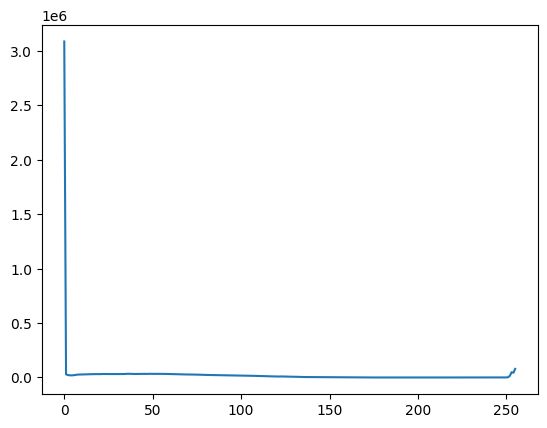

SIZE (1800, 3600)
index: 0
index: 1796
index: 6465600
index: 0
0 898 2392 3592
(1800, 3600, 3)
LEVEL 30 215


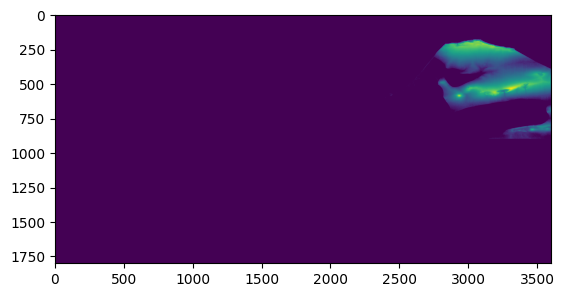

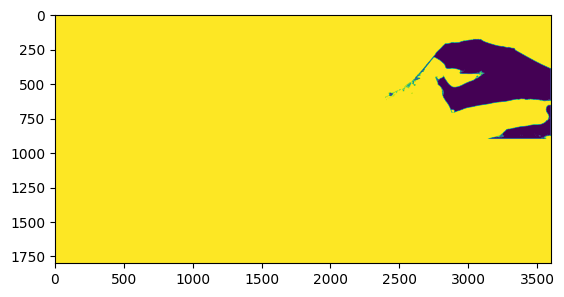

index: 0
index: 1796
index: 4305600
index: 0
0 898 1194 2392
(1800, 3600, 3)
LEVEL 30 215


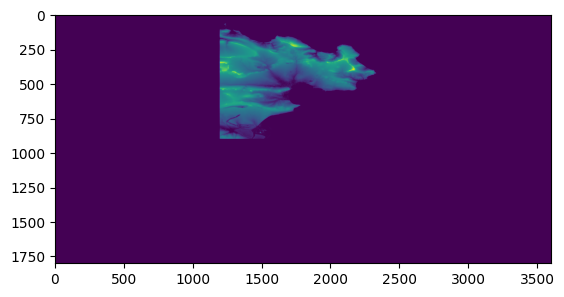

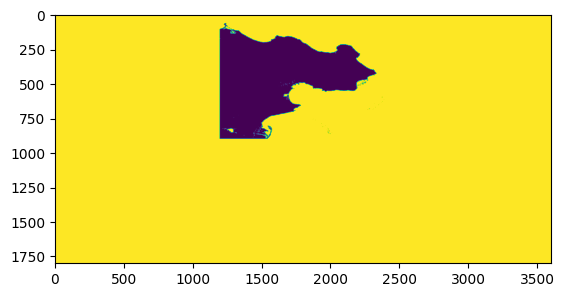

index: 0
index: 1796
index: 2149200
index: 0
0 898 0 1194
(1800, 3600, 3)
LEVEL 30 215


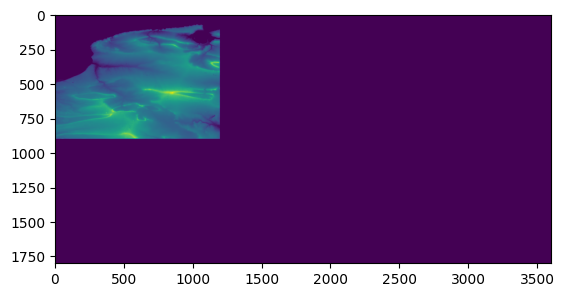

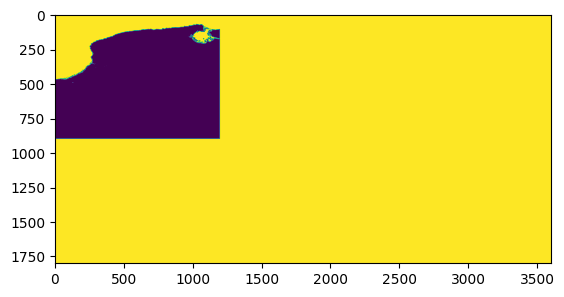

index: 1796
index: 3596
index: 6465600
index: 0
898 1798 2392 3592
(1800, 3600, 3)
LEVEL 30 215


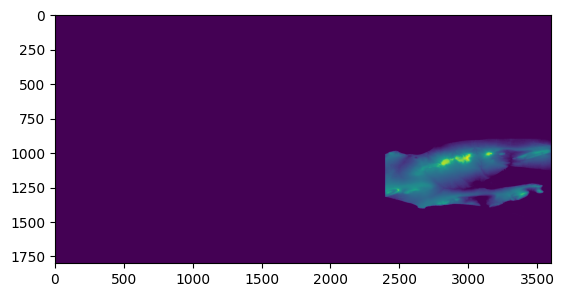

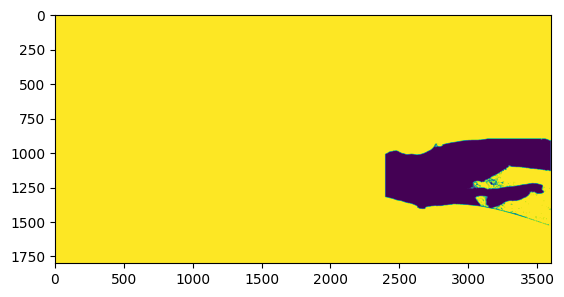

index: 1796
index: 3596
index: 4305600
index: 0
898 1798 1194 2392
(1800, 3600, 3)
LEVEL 30 215


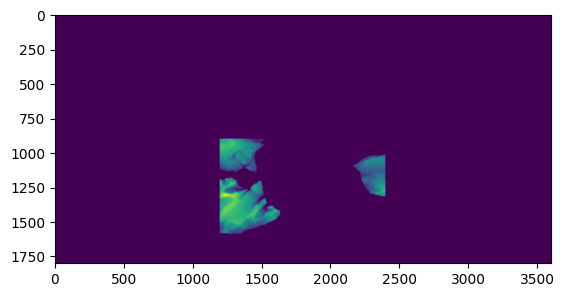

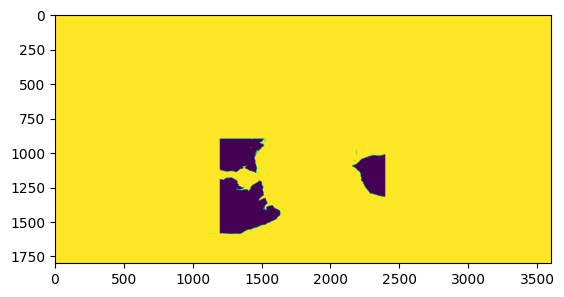

index: 1796
index: 3596
index: 2149200
index: 0
898 1798 0 1194
(1800, 3600, 3)
LEVEL 30 215


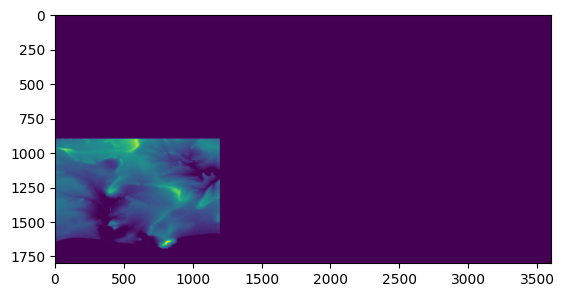

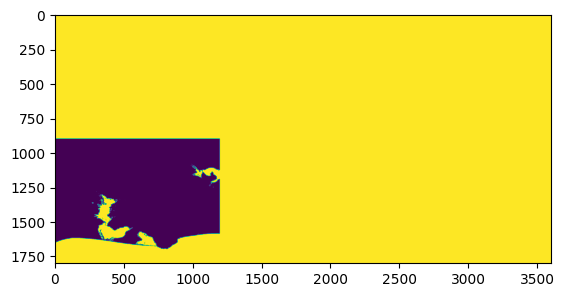

6


In [ ]:
#water_level = {level ; [lon; lat]}
import numpy as np
import matplotlib.image
import pandas as pd
import numpy as np
import cv2 as cv
import matplotlib.image
from shapely.geometry import Polygon
import requests as rs
import os
from matplotlib import pyplot as plt


import plotly.graph_objects as go
import PIL
from PIL import Image
import plotly.express as px

R = 6360000

def cc_to_ll(x, y):
    r = math.sqrt(x**2 + y**2)
    lon = 180 * math.atan2(y,x)/math.pi
    lat = 180 * math.acos(r/R)/math.pi
    return [lat, lon]

def filter_odd_num(element):
  if(len(element) > 10):
    return True
  else:
    return False

def filter_square(element):
  pg = np.reshape(element, (element.shape[0], element.shape[2]))
  if(Polygon(pg).area > 12):
    return True
  else:
    return False



def limit_contours(limit : list, waterLevel : list, out_csv : str, image : str):
  myRasterDF = pd.read_csv(out_csv)
  res = myRasterDF.z.values
  avgX = np.average(myRasterDF['x'])
  avgY = np.average(myRasterDF['y'])
  sizeY = myRasterDF['y'].nunique()
  sizeX = myRasterDF['x'].nunique()
  print(np.min(myRasterDF['x']), np.max(myRasterDF['x']), np.min(myRasterDF['y']), np.max(myRasterDF['y']))
  print(np.min(myRasterDF['z']), np.max(myRasterDF['z']))
  difx = (np.max(myRasterDF['x']) - np.max(myRasterDF['x']))/sizeX
  dify = (np.min(myRasterDF['y']) - np.min(myRasterDF['y']))/sizeY
  res = np.array(np.reshape(res, (sizeY, sizeX)), dtype='uint8')
  from skimage.exposure import histogram
  hist_g, bins_g = histogram(res)
  plt.plot(bins_g, hist_g)
  plt.show()
  print("SIZE",(sizeY, sizeX))
  list_polig = []
  for lim in range(len(limit)):
    left = myRasterDF[(limit[lim][0] - 0.001)<=myRasterDF['x']]
    left = left[(limit[lim][0] + 0.001)>=left['x']]
    print("index:",left.index[0])
    left = int(left.index[0]/2)
    right = myRasterDF[(limit[lim][1] - 0.001)<=myRasterDF['x']]
    right = right[(limit[lim][1] + 0.001)>=right['x']]
    print("index:",right.index[0])
    right = int(right.index[0]/2)
    top = myRasterDF[(limit[lim][2] - 0.001)<=myRasterDF['y']]
    top = top[(limit[lim][2] + 0.001)>=top['y']]
    print("index:",top.index[0])
    top = int(top.index[0]/sizeY)
    floor = myRasterDF[(limit[lim][3] - 0.001)<=myRasterDF['y']]
    print("index:",floor.index[0])
    floor = floor[(limit[lim][3] + 0.001)>=floor['y']]
    floor = int(floor.index[0]/sizeY)
    print(left, right, floor, top)
    if len(np.where(res == waterLevel[lim])[0]) != 0:
      indX = np.where(res[left:right, floor:top] == waterLevel[lim])[0][0]+left
      indY = np.where(res[left:right, floor:top] == waterLevel[lim])[1][0]+floor
      img = np.array(cv.imread(image, 1))
      print(img.shape)
      imgray = np.array(cv.cvtColor(img, cv.COLOR_BGR2GRAY))
      min = np.min(imgray)
      max = np.max(imgray)
      imgray[:,:floor] = min
      imgray[:,top:] = min
      imgray[:left,:] = min
      imgray[right:,:] = min
      print("LEVEL", min, max)
      plt.imshow(imgray)
      plt.show()
      #matplotlib.image.imsave("/content/drive/MyDrive/krim_tresh"+str(lim)+".png", imgray)

      retval, threshold = cv.threshold(imgray, imgray[indX][indY], 255, cv.THRESH_BINARY_INV)
      plt.imshow(threshold)
      plt.show()
      contours, hierarchy = cv.findContours(threshold,cv.RETR_TREE,cv.CHAIN_APPROX_NONE)
      contours = list(contours)
      eps = 0.0005
      sq = []
      contours = filter(filter_odd_num, contours)
      contours = list(contours)
      for i in range(0, len(contours)):
        pg = np.reshape(contours[i], (contours[i].shape[0], contours[i].shape[2]))
        sq.append(Polygon(pg).area)
      for i in range(0, len(contours)):
        arclen = cv.arcLength(contours[i], True)
        epsilon = arclen * eps
        contours[i] = cv.approxPolyDP(contours[i], epsilon, True)
      contours = tuple(contours)
      List = []
      for i in contours:
        poligon = []
        for k in i:
          poligon.append([myRasterDF['x'][k[0][1] * sizeX + k[0][0]], myRasterDF['y'][k[0][1] * sizeX + k[0][0]]])
        List.append(poligon)
    list_polig.append(List)
  return list_polig


def tile_division(coord_level : list, max : list, min : list):
  X = (np.floor(np.sqrt(len(coord_level))))
  Y = X + 1
  print("size",X,Y)
  X = np.arange(min[0], max[0]+(max[0]/X-min[0]/X), (max[0]-min[0])/X)
  Y = np.arange(min[1], max[1]+(max[1]/Y-min[1]/Y), (max[1]-min[1])/Y)
  print("size", len(X), len(Y))
  tiles = []
  level = []
  for i in range(len(X)-1):
    for j in range(len(Y)-1):
      tiles.append([X[i], X[i+1], Y[j], Y[j+1]])
  print(len(tiles))
  for coord in tiles:
    avg = 0
    count = 0
    for point in coord_level:
      if coord[0] <= point[0] <= coord[1] and coord[2] <= point[1] <= coord[3]:
        avg += point[2]
        count += 1

    if count == 0:
      level.append(0)
    else:
      level.append(int(avg/count))
  level = np.array(level).reshape(len(X)-1, len(Y)-1)
  condition = (level == 0)
  level[condition] = np.mean(level)
  level = list(level.reshape((len(X)-1)*(len(Y)-1)))
  return tiles, level

import plotly.graph_objects as go

10 - 4*3 -9


lon = [36.566666666666664, 36.6666,36.8676,36.37666,36.42]
lat = [45.21,45.2245,45.2345,45.2945,45.285]
tiles, level = tile_division([[36.566666666666664, 45.21, 10],[36.6666, 45.2245, 0],[36.8676, 45.2345, 0],[36.37666, 45.2945,0],[36.42, 45.285,0]], [36.999861111141634,45.499861111105630], [36.000138888919274, 45.00013888888334])
print(level)
res = limit_contours(tiles, level, '/content/drive/MyDrive/Krim_xyz.csv', '/content/drive/MyDrive/Krim_photo.png')
print(len(res))
fig = go.Figure(go.Scattermapbox(lat=lat, lon=lon))



fig.update_layout(
    mapbox = {
        'style': "open-street-map",
        'zoom': 10, 'layers': [{
            'source': {
                'type': "FeatureCollection",
                'features': [{
                    'type': "Feature",
                    'geometry': {
                        'type': "MultiPolygon",
                        'coordinates': res
                    }
                }]
            },
            'type': "fill", 'below': "traces", 'color' : "red"}]},
    legend = {'bgcolor' : "red"},
    margin = {'l':0, 'r':0, 'b':0, 't':0})


fig.show()


###Интерполяция по тайлам

size 2.0 3.0
size 3 4
[[1 1 2 4]
 [1 1 2 4]
 [5 5 5 4]]
[[1, 1, 1], [1, 2, 1], [2, 4, 2], [1, 1, 5], [1, 2, 5], [2, 4, 5]]


<ipython-input-51-d20bce883289>:14: DeprecationWarning:

`interp2d` is deprecated!
`interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.13.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://scipy.github.io/devdocs/notebooks/interp_transition_guide.html`


/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_fitpack_impl.py:593: RuntimeWarning:

The required storage space exceeds the available storage space.
Probable causes: nxest or nyest too small or s is too small. (fp>s)
	kx,ky=1,1 nx,ny=4,4 m=5 fp=0.494071 s=0.000000

<ipython-input-51-d20bce883289>:15: DeprecationWarning:

        `interp2d` is deprecated!
        `interp2d` is deprecated in SciPy 1.10 and will be removed i

SIZE (1800, 3600)
index: 0
index: 1796
index: 6465600
index: 0
0 898 2392 3592
Z: [[1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 ...
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]]
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]


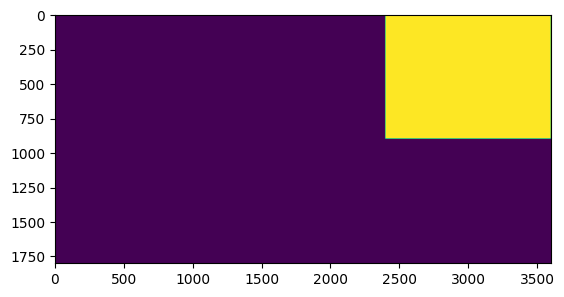

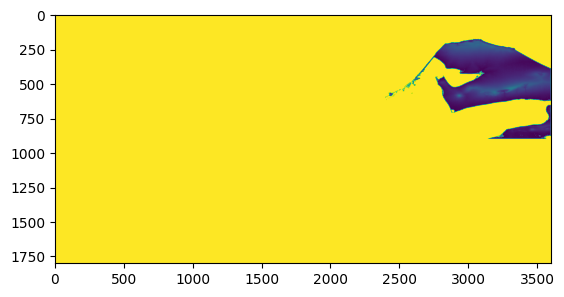

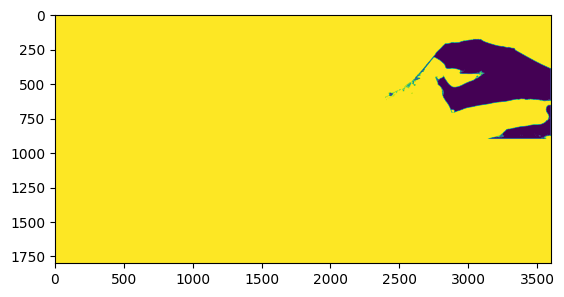

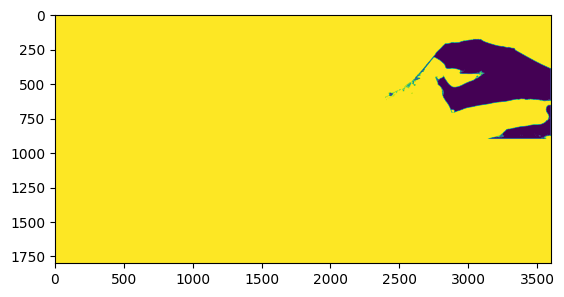

index: 0
index: 1796
index: 4305600
index: 0
0 898 1194 2392
Z: [[1.         1.         1.         ... 1.         1.         1.        ]
 [1.00111359 1.00111359 1.00111359 ... 1.00111359 1.00111359 1.00111359]
 [1.00222717 1.00222717 1.00222717 ... 1.00222717 1.00222717 1.00222717]
 ...
 [1.99665924 1.99665924 1.99665924 ... 1.99665924 1.99665924 1.99665924]
 [1.99777283 1.99777283 1.99777283 ... 1.99777283 1.99777283 1.99777283]
 [1.99888641 1.99888641 1.99888641 ... 1.99888641 1.99888641 1.99888641]]
[[1 1 1 ... 1 1 1]
 [2 2 2 ... 2 2 2]
 [2 2 2 ... 2 2 2]
 ...
 [2 2 2 ... 2 2 2]
 [2 2 2 ... 2 2 2]
 [2 2 2 ... 2 2 2]]


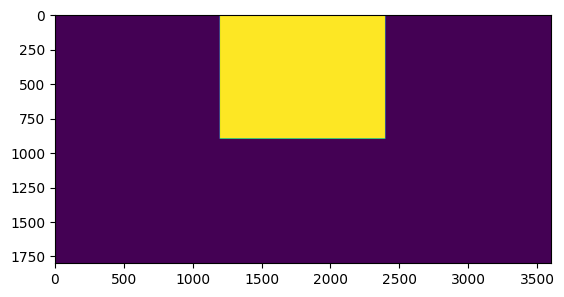

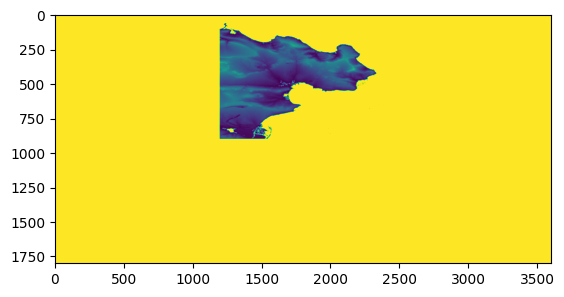

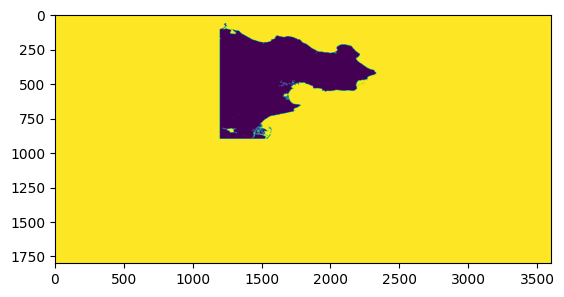

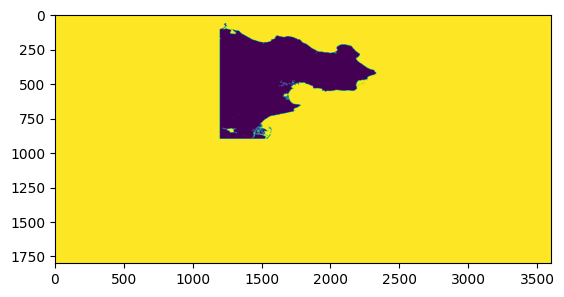

index: 0
index: 1796
index: 2149200
index: 0
0 898 0 1194
Z: [[2.         2.         2.         ... 2.         2.         2.        ]
 [2.00222717 2.00222717 2.00222717 ... 2.00222717 2.00222717 2.00222717]
 [2.00445434 2.00445434 2.00445434 ... 2.00445434 2.00445434 2.00445434]
 ...
 [3.99331849 3.99331849 3.99331849 ... 3.99331849 3.99331849 3.99331849]
 [3.99554566 3.99554566 3.99554566 ... 3.99554566 3.99554566 3.99554566]
 [3.99777283 3.99777283 3.99777283 ... 3.99777283 3.99777283 3.99777283]]
[[2 2 2 ... 2 2 2]
 [3 3 3 ... 3 3 3]
 [3 3 3 ... 3 3 3]
 ...
 [4 4 4 ... 4 4 4]
 [4 4 4 ... 4 4 4]
 [4 4 4 ... 4 4 4]]


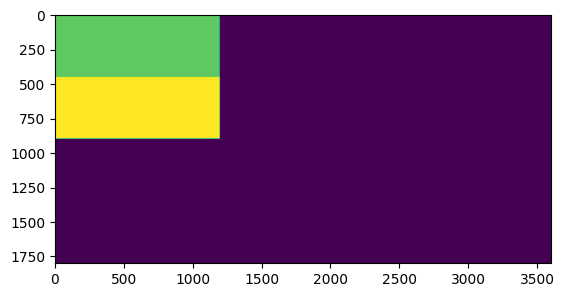

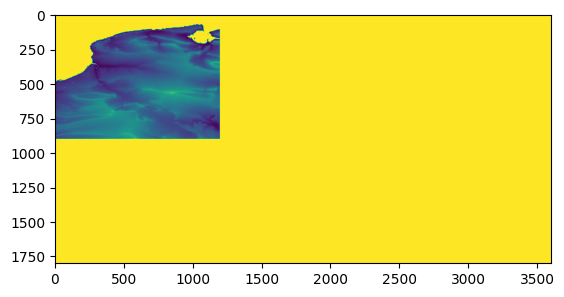

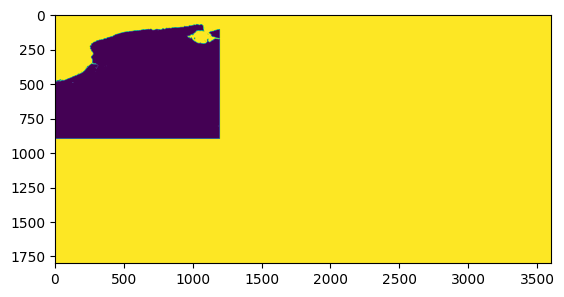

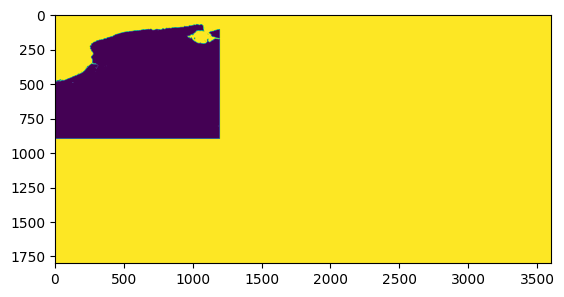

index: 1796
index: 3596
index: 6465600
index: 0
898 1798 2392 3592
Z: [[12.97333333 12.97       12.96666667 ...  8.98333333  8.98
   8.97666667]
 [12.97333333 12.97       12.96666667 ...  8.98333333  8.98
   8.97666667]
 [12.97333333 12.97       12.96666667 ...  8.98333333  8.98
   8.97666667]
 ...
 [12.97333333 12.97       12.96666667 ...  8.98333333  8.98
   8.97666667]
 [12.97333333 12.97       12.96666667 ...  8.98333333  8.98
   8.97666667]
 [12.97333333 12.97       12.96666667 ...  8.98333333  8.98
   8.97666667]]
[[13 13 13 ...  9  9  9]
 [13 13 13 ...  9  9  9]
 [13 13 13 ...  9  9  9]
 ...
 [13 13 13 ...  9  9  9]
 [13 13 13 ...  9  9  9]
 [13 13 13 ...  9  9  9]]


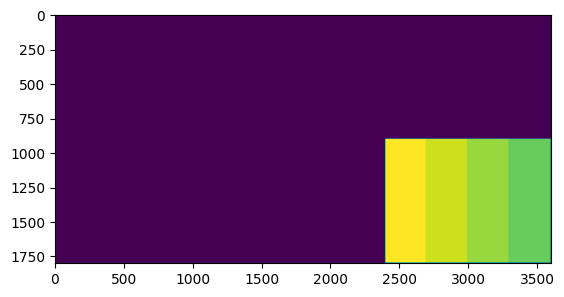

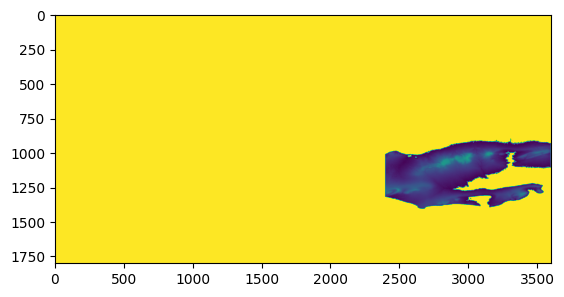

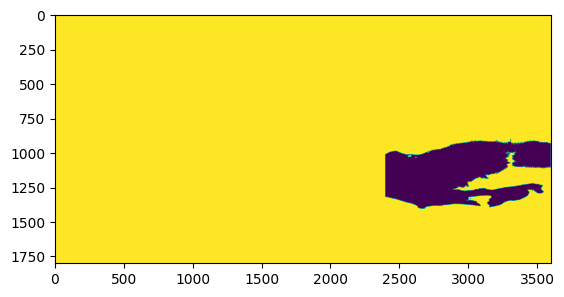

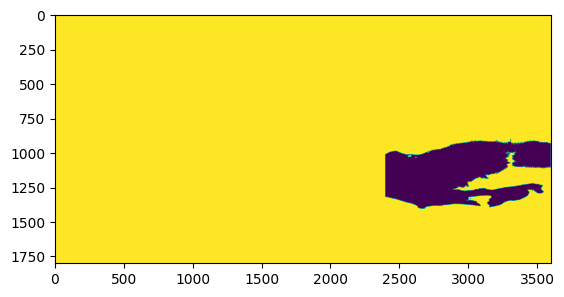

index: 1796
index: 3596
index: 4305600
index: 0
898 1798 1194 2392
Z: [[7.98886663 7.98552773 7.98218883 ... 3.99888332 3.99554443 3.99220553]
 [7.98997774 7.98663884 7.98329994 ... 3.99999444 3.99665554 3.99331664]
 [7.99108885 7.98774995 7.98441106 ... 4.00110555 3.99776665 3.99442775]
 ...
 [8.9855333  8.9821944  8.9788555  ... 4.99554999 4.99221109 4.98887219]
 [8.98664441 8.98330551 8.97996661 ... 4.9966611  4.9933222  4.98998331]
 [8.98775552 8.98441662 8.98107772 ... 4.99777221 4.99443331 4.99109442]]
[[8 8 8 ... 4 4 4]
 [8 8 8 ... 4 4 4]
 [8 8 8 ... 5 4 4]
 ...
 [9 9 9 ... 5 5 5]
 [9 9 9 ... 5 5 5]
 [9 9 9 ... 5 5 5]]


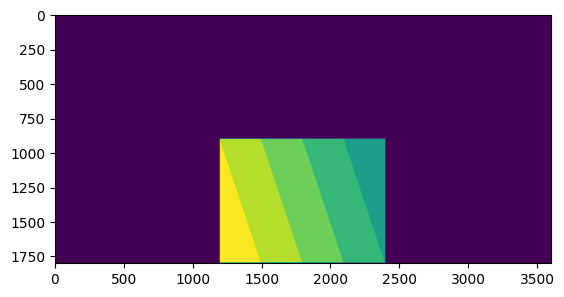

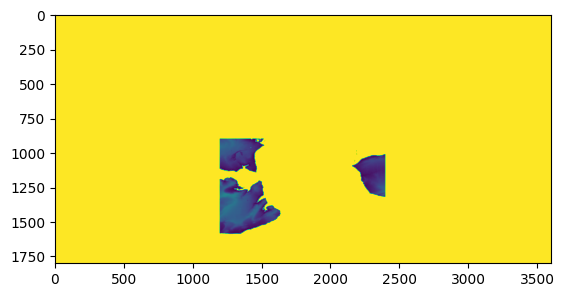

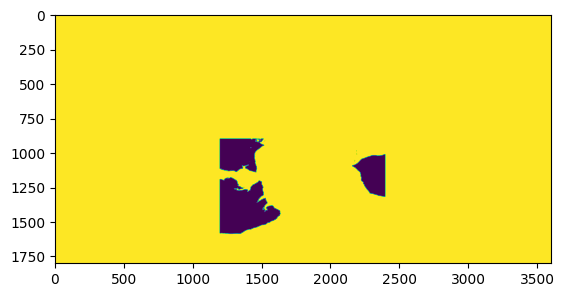

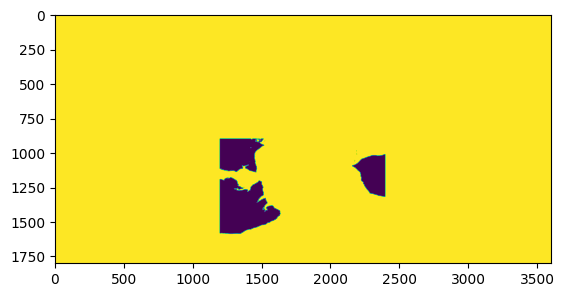

index: 1796
index: 3596
index: 2149200
index: 0
898 1798 0 1194
Z: [[3.00444444 3.00193188 2.99941932 ... 0.01198213 0.00946957 0.00695701]
 [3.00666667 3.0041541  3.00164154 ... 0.01420436 0.01169179 0.00917923]
 [3.00888889 3.00637633 3.00386376 ... 0.01642658 0.01391401 0.01140145]
 ...
 [4.99777778 4.99526521 4.99275265 ... 2.00531547 2.0028029  2.00029034]
 [5.         4.99748744 4.99497487 ... 2.00753769 2.00502513 2.00251256]
 [5.00222222 4.99970966 4.9971971  ... 2.00975991 2.00724735 2.00473479]]
[[4 4 3 ... 1 1 1]
 [4 4 4 ... 1 1 1]
 [4 4 4 ... 1 1 1]
 ...
 [5 5 5 ... 3 3 3]
 [5 5 5 ... 3 3 3]
 [6 5 5 ... 3 3 3]]


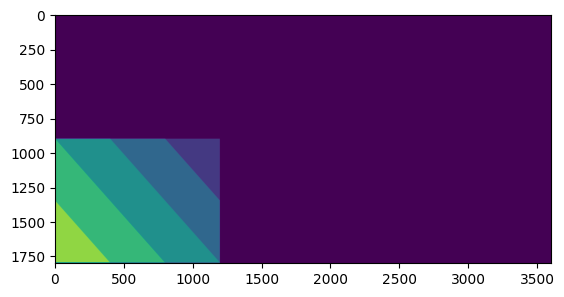

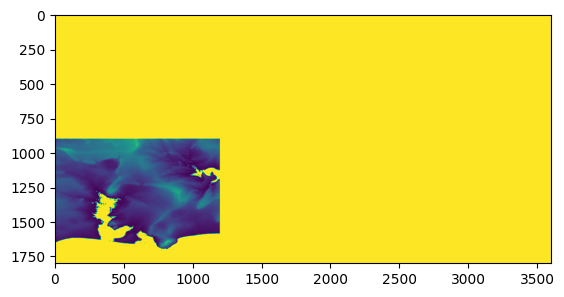

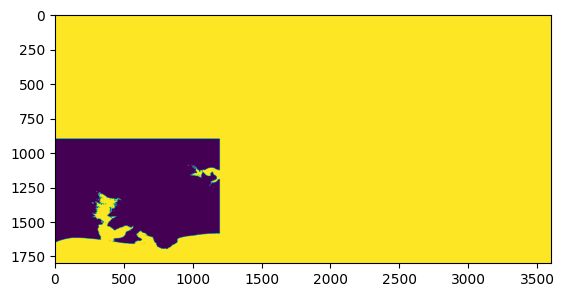

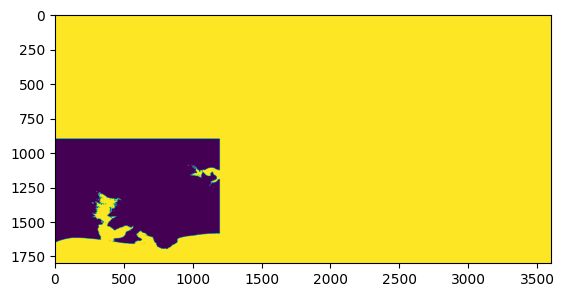

6


In [ ]:
from scipy.interpolate import interp2d
def tile_division(coord_level : list, max : list, min : list):
  X = (np.floor(np.sqrt(len(coord_level))))
  Y = X + 1
  print("size",X,Y)
  X = np.arange(min[0], max[0]+(max[0]/X-min[0]/X), (max[0]-min[0])/X)
  Y = np.arange(min[1], max[1]+(max[1]/Y-min[1]/Y), (max[1]-min[1])/Y)
  print("size", len(X), len(Y))
  tiles = []
  level = []
  for i in range(len(X)-1):
    for j in range(len(Y)-1):
      tiles.append([X[i], X[i+1], Y[j], Y[j+1]])
  f = interp2d((np.array(coord_level)[:,1]-min[1])*len(Y)/(max[1]-min[1]),(np.array(coord_level)[:,0]-min[0])*len(X)/(max[0]-min[0]), np.array(coord_level)[:,2])
  res = f(np.arange(0,len(Y)), np.arange(0,len(X)))
  res = np.array(np.floor(res), dtype='int8')
  res[res<0] = 0
  print(res)
  level = []
  for i in range((len(X)-1)):
    for j in range((len(Y)-1)):
      level.append([res[i][j],res[i][j+1],res[i+1][j]])
  return tiles, level

import numpy as np
import matplotlib.image
import pandas as pd
import numpy as np
import cv2 as cv
import matplotlib.image
from shapely.geometry import Polygon
import requests as rs
import os
from matplotlib import pyplot as plt


import plotly.graph_objects as go

R = 6360000

def cc_to_ll(x, y):
    r = math.sqrt(x**2 + y**2)
    lon = 180 * math.atan2(y,x)/math.pi
    lat = 180 * math.acos(r/R)/math.pi
    return [lat, lon]

def filter_odd_num(element):
  if(len(element) > 10):
    return True
  else:
    return False

def filter_square(element):
  pg = np.reshape(element, (element.shape[0], element.shape[2]))
  if(Polygon(pg).area > 12):
    return True
  else:
    return False

def limit_contours(limit : list, waterLevel : list, out_csv : str):
  myRasterDF = pd.read_csv(out_csv)
  res = myRasterDF.z.values
  avgX = np.average(myRasterDF['x'])
  avgY = np.average(myRasterDF['y'])
  sizeY = myRasterDF['y'].nunique()
  sizeX = myRasterDF['x'].nunique()
  #print(np.min(myRasterDF['x']), np.max(myRasterDF['x']), np.min(myRasterDF['y']), np.max(myRasterDF['y']))
  res = np.array(np.reshape(res, (sizeY, sizeX)), dtype='uint32')
  print("SIZE",(sizeY, sizeX))
  list_polig = []
  for lim in range(len(limit)):
    left = myRasterDF[(limit[lim][0] - 0.001)<=myRasterDF['x']]
    left = left[(limit[lim][0] + 0.001)>=left['x']]
    print("index:",left.index[0])
    left = int(left.index[0]/2)
    right = myRasterDF[(limit[lim][1] - 0.001)<=myRasterDF['x']]
    right = right[(limit[lim][1] + 0.001)>=right['x']]
    print("index:",right.index[0])
    right = int(right.index[0]/2)
    top = myRasterDF[(limit[lim][2] - 0.001)<=myRasterDF['y']]
    top = top[(limit[lim][2] + 0.001)>=top['y']]
    print("index:",top.index[0])
    top = int(top.index[0]/sizeY)
    floor = myRasterDF[(limit[lim][3] - 0.001)<=myRasterDF['y']]
    print("index:",floor.index[0])
    floor = floor[(limit[lim][3] + 0.001)>=floor['y']]
    floor = int(floor.index[0]/sizeY)
    print(left, right, floor, top)
    if len(np.where(res == int(np.average(waterLevel[lim])))[0]) != 0:
      #добавить индексы угловых высот
      #indexes = [[np.where(res[left:right, floor:top] == waterLevel[lim][0])[0][0]+left, np.where(res[left:right, floor:top] == waterLevel[lim][0])[1][0]+floor],[np.where(res[left:right, floor:top] == waterLevel[lim][1])[0][0]+left, np.where(res[left:right, floor:top] == waterLevel[lim][1])[1][0]+floor],[np.where(res[left:right, floor:top] == waterLevel[lim][2])[0][0]+left, np.where(res[left:right, floor:top] == waterLevel[lim][0])[1][0]+floor]]
      #img = np.array(cv.imread(image, 1))
      #imgray = np.array(cv.cvtColor(img, cv.COLOR_BGR2GRAY))
      min = np.min(res)
      max = np.max(res)
      copy = res.copy()
      copy[:,:floor] = max
      copy[:,top:] = max
      copy[:left,:] = max
      copy[right:,:] = max

      # Вычисляем векторы, лежащие на плоскости
      vector1 = np.array([right, top, waterLevel[lim][1]]) - np.array([left, floor, waterLevel[lim][2]])
      vector2 = np.array([left, top, waterLevel[lim][0]]) - np.array([left, floor, waterLevel[lim][2]])

      # Нормаль к плоскости - векторное произведение векторов
      normal = np.cross(vector1, vector2)

      # Вычисляем коэффициенты уравнения плоскости ax + by + cz + d = 0
      a, b, c = normal
      d = -np.dot(normal, np.array([left, floor, waterLevel[lim][2]]))
      # Создаем сетку точек для построения плоскости
      x = np.arange(right-left)
      y = np.arange(top-floor)
      Y, X = np.meshgrid(y, x)
      Z = (-a*X - b*Y - d) / c
      print("Z:", Z)
      mask = np.zeros(res.shape, dtype='uint32')
      mask[left:right,floor:top] = np.ceil(np.array(Z))
      print(mask[left:right,floor:top])
      copy = copy - mask
      plt.imshow(mask)
      plt.show()
      image = np.uint8(np.clip(copy, 0, 255))
      plt.imshow(image)
      plt.show()
      image[copy<255] = 0
      plt.imshow(image)
      plt.show()
      retval, threshold = cv.threshold(image, 200, 255, cv.THRESH_BINARY)
      plt.imshow(threshold)
      plt.show()
      contours, hierarchy = cv.findContours(threshold.astype(np.uint8), cv.RETR_TREE,cv.CHAIN_APPROX_NONE)
      contours = list(contours)
      eps = 0.0005
      contours = filter(filter_odd_num, contours)
      contours = list(contours)
      for i in range(0, len(contours)):
        arclen = cv.arcLength(contours[i], True)
        epsilon = arclen * eps
        contours[i] = cv.approxPolyDP(contours[i], epsilon, True)
      contours = tuple(contours)
      List = []
      for i in contours:
        poligon = []
        for k in i:
          poligon.append([myRasterDF['x'][k[0][1] * sizeX + k[0][0]], myRasterDF['y'][k[0][1] * sizeX + k[0][0]]])
        List.append(poligon)
    list_polig.append(List)
  return list_polig

lon = [36.566666666666664, 36.6666,36.8676,36.37666,36.42]
lat = [45.21,45.2245,45.2345,45.2945,45.285]
tiles, level = tile_division([[36.566666666666664, 45.21, 4],[36.6666, 45.2245,6],[36.8676, 45.2345, 7],[36.37666, 45.2945,4],[36.42, 45.285,4]], [36.999861111141634,45.499861111105630], [36.000138888919274, 45.00013888888334])
print(level)
res = limit_contours(tiles, level, '/content/drive/MyDrive/Krim_xyz.csv')
print(len(res))
fig = go.Figure(go.Scattermapbox(lat=lat, lon=lon))



fig.update_layout(
    mapbox = {
        'style': "open-street-map",
        'zoom': 10, 'layers': [{
            'source': {
                'type': "FeatureCollection",
                'features': [{
                    'type': "Feature",
                    'geometry': {
                        'type': "MultiPolygon",
                        'coordinates': res
                    }
                }]
            },
            'type': "fill", 'below': "traces", 'color' : "red"}]},
    legend = {'bgcolor' : "red"},
    margin = {'l':0, 'r':0, 'b':0, 't':0})


fig.show()



###Конечный вариант

In [ ]:
from scipy.interpolate import interp2d
import numpy as np
import pandas as pd
import cv2 as cv
from matplotlib import pyplot as plt
import plotly.graph_objects as go

def tile_division(coord_level : list, max : list, min : list):
  X = (np.floor(np.sqrt(len(coord_level))))
  Y = X + 1
  shape = [X,Y]
  X = list(np.arange(min[0], max[0], (max[0]-min[0])/X))
  Y = list(np.arange(min[1], max[1], (max[1]-min[1])/Y))
  X.append(max[0])
  Y.append(max[1])
  tiles = []
  level = []
  for i in range(len(X)-1):
    for j in range(len(Y)-1):
      tiles.append([X[i], X[i+1], Y[j], Y[j+1]])
  f = interp2d((np.array(coord_level)[:,1]-min[1])*len(Y)/(max[1]-min[1]),(np.array(coord_level)[:,0]-min[0])*len(X)/(max[0]-min[0]), np.array(coord_level)[:,2])
  res = f(np.arange(0,len(Y)), np.arange(0,len(X)))
  res = np.array(np.floor(res), dtype='int32')
  res[res<0] = 0
  level = []
  for i in range((len(X)-1)):
    for j in range((len(Y)-1)):
      level.append([res[i][j],res[i][j+1],res[i+1][j]])
  return tiles, level, shape

def filter_odd_num(element):
  if(len(element) > 10):
    return True
  else:
    return False

def limit_contours(coord_level : list, out_csv : str):
  myRasterDF = pd.read_csv(out_csv)
  data = myRasterDF.z.values
  avgX = np.average(myRasterDF['x'])
  avgY = np.average(myRasterDF['y'])
  sizeY = myRasterDF['y'].nunique()
  sizeX = myRasterDF['x'].nunique()
  # Получение координат и значений высоты для каждого тайла
  limit, waterLevel, shape = tile_division(coord_level, [np.max(myRasterDF['x']), np.max(myRasterDF['y'])], [np.min(myRasterDF['x']),np.min(myRasterDF['y'])])
  data = np.array(np.reshape(data, (sizeY, sizeX)), dtype='float32')
  list_polig = []
  for lim in range(len(limit)):
    floor = int(sizeX - ((lim % shape[1])+1)*(sizeX/shape[1]) - 1) if (sizeX - ((lim % shape[1])+1)*(sizeX/shape[1]) > 0) else int(sizeX - ((lim % shape[1])+1)*(sizeX/shape[1]))
    top = int(sizeX - ((lim % shape[1]))*(sizeX/shape[1]) - 1) if (sizeX - ((lim % shape[1]))*(sizeX/shape[1]) > 0) else int(sizeX - ((lim % shape[1]))*(sizeX/shape[1]))
    left = int(((lim % shape[0]))*(sizeY/shape[0]) - 1) if (((lim % shape[0]))*(sizeY/shape[0]) > 0) else int(((lim % shape[0]))*(sizeY/shape[0]))
    right = int(((lim % shape[0])+1)*(sizeY/shape[0]) - 1) if (((lim % shape[0])+1)*(sizeY/shape[0]) > 0) else int(((lim % shape[0])+1)*(sizeY/shape[0]))
    if len(np.where(data == int(np.average(waterLevel[lim])))[0]) != 0:
      min = np.min(data)
      earth_rel = data.copy()
      # Закрашиваем всё кроме нужного тайла в минимальный цвет
      earth_rel[:,:floor] = min
      earth_rel[:,top:] = min
      earth_rel[:left,:] = min
      earth_rel[right:,:] = min
      # Вычисляем векторы, лежащие на плоскости воды
      vector1 = np.array([right, top, waterLevel[lim][1]]) - np.array([left, floor, waterLevel[lim][2]])
      vector2 = np.array([left, top, waterLevel[lim][0]]) - np.array([left, floor, waterLevel[lim][2]])
      # Нормаль к плоскости - векторное произведение векторов
      normal = np.cross(vector1, vector2)
      # Вычисляем коэффициенты уравнения плоскости ax + by + cz + d = 0
      a, b, c = normal
      d = -np.dot(normal, np.array([left, floor, waterLevel[lim][2]]))
      # Создаем сетку точек для построения плоскости
      x = np.arange(right-left)
      y = np.arange(top-floor)
      Y, X = np.meshgrid(y, x)
      Z = (-a*X - b*Y - d) / c
      # Записываем в water_rel плоскость воды
      water_rel = np.zeros(data.shape, dtype='float32')
      water_rel[left:right, floor:top] = np.ceil(np.array(Z))
      #вычитаем из исходных данных плоскость воды(для получения пересечений с водой)
      new_earth_rel = earth_rel - water_rel
      image = np.uint8(np.where(new_earth_rel>0, 1, 0))
      contours, hierarchy = cv.findContours(image.astype(np.uint8), cv.RETR_TREE,cv.CHAIN_APPROX_NONE)
      contours = list(contours)
      eps = 0.0005
      contours = filter(filter_odd_num, contours)
      contours = list(contours)
      for i in range(0, len(contours)):
        arclen = cv.arcLength(contours[i], True)
        epsilon = arclen * eps
        contours[i] = cv.approxPolyDP(contours[i], epsilon, True)
      contours = tuple(contours)
      List = []
      for i in contours:
        poligon = []
        for k in i:
          poligon.append([myRasterDF['x'][k[0][1] * sizeX + k[0][0]], myRasterDF['y'][k[0][1] * sizeX + k[0][0]]])
        List.append(poligon)
    list_polig.append(List)
  return list_polig

lon = [36.566666666666664, 36.6666,36.8676,36.37666,36.42]
lat = [45.21,45.2245,45.2345,45.2945,45.285]
#tiles, level = tile_division([[36.566666666666664, 45.21, 4],[36.6666, 45.2245,6],[36.8676, 45.2345, 7],[36.37666, 45.2945,4],[36.42, 45.285,4]], [36.999861111141634,45.499861111105630], [36.000138888919274, 45.00013888888334])
#print(level) [[49.766666666666664, 53.49, 14],[49.96666666666664, 53.3,57],[50.266666666666664, 53.29, 57],[50.306666666666664, 53.39,54]]
res = limit_contours([[36.566666666666664, 45.21, 4],[36.6666, 45.2245,6],[36.8676, 45.2345, 7],[36.37666, 45.2945,4],[36.42, 45.285,4]], '/content/drive/MyDrive/Krim_xyz.csv')

fig = go.Figure(go.Scattermapbox(lat=lat, lon=lon))

fig.update_layout(
    mapbox = {
        'style': "open-street-map",
        'zoom': 10, 'layers': [{
            'source': {
                'type': "FeatureCollection",
                'features': [{
                    'type': "Feature",
                    'geometry': {
                        'type': "MultiPolygon",
                        'coordinates': res
                    }
                }]
            },
            'type': "fill", 'below': "traces", 'color' : "red"}]},
    legend = {'bgcolor' : "red"},
    margin = {'l':0, 'r':0, 'b':0, 't':0})
fig.show()



<ipython-input-6-bbfe86470601>:21: DeprecationWarning:

`interp2d` is deprecated!
`interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.13.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://scipy.github.io/devdocs/notebooks/interp_transition_guide.html`


/usr/local/lib/python3.10/dist-packages/scipy/interpolate/_fitpack_impl.py:593: RuntimeWarning:

The required storage space exceeds the available storage space.
Probable causes: nxest or nyest too small or s is too small. (fp>s)
	kx,ky=1,1 nx,ny=4,4 m=5 fp=0.494071 s=0.000000

<ipython-input-6-bbfe86470601>:22: DeprecationWarning:

        `interp2d` is deprecated!
        `interp2d` is deprecated in SciPy 1.10 and will be removed in 